##Q1 - Sequência de Fibonacci

<table><tbody><tr><td>
$$
\begin{aligned}
a_0 &= 0 \\
a_1 &= 1 \\
a_k &= a_{k-1} + a_{k-2}, \quad k=2, 3, \dots
\end{aligned}
$$
</td></tr></tbody></table>

- Implementar em python a sequência de Fibonacci. Programar-lo armazenando os resultados num vetor e programar-lo usando o conceito de recorrência, i.e., onde a função chama-se a si mesmo tantas vezes quanto necessário para calcular os elementos da sequência.

In [ ]:
# no Fibonacci todo numero novo é a soma dos dois anteriores
# sendo os dois primeiros numeros 0 e 1

import numpy as np

# vai gerar um vetor com n numeros
def vetor_fibonacci(n):
  if n <= 0:
    return [0]
  elif n == 1:
    return [0, 1]

  # criar um vetor com dois numeros iniciais (a0, a1)
  vetor = [0, 1]

  # acrescenta valores nesse vetor a partir da posição 2 ate a posição n
  for k in range(2, n + 1):
    # somas os dois antecessores
    vetor.append(vetor[k-1] + vetor[k-2])

  return vetor

# essa função nao cria um vetor, apenas calcula um termo específico desejado (k)
def termo_fibonacci(k):
  if k == 0:
    return 0
  if k == 1:
    return 1
  # se nao tiver um termo ele vai atras desse termo ate achar o valor
  return termo_fibonacci(k - 1) + termo_fibonacci(k - 2)

# ela usa os valores encontrados na função anterior para criar uma lista
def sequencia_fibonacci(n):
  sequencia = []
  for i in range(n + 1):
    sequencia.append(termo_fibonacci(i))
  return sequencia

n = 10
print(vetor_fibonacci(n))
print(sequencia_fibonacci(n))


##Q2 - Iteração de ponto fixo

- Dada uma função $\varphi(x)$, a iteração de ponto fixo é definida por

<table><tbody><tr><td>
$$
x_{k+1} = \varphi(x_k)
$$
</td></tr></tbody></table>

- Com $x_0$ dado, diz-se que $\bar{x}$ é ponto fixo da função $\varphi$ se $\bar{x} = \varphi(\bar{x})$ e a iteração de ponto fixo diz-se convergente se:

<table><tbody><tr><td>
$$
\lim_{k \to \infty} x_k = \bar{x}
$$
</td></tr></tbody></table>


- Fazer um programa de python que executa o processo de iteração de ponto fixo do exemplo (c) para a função $\varphi(x) = 1/\sqrt{x}$ e graficar o processo iterativo como mostrado na figura ao lado. Notar que a condição inicial escolhida no exemplo é $x_0 = 0.75$.


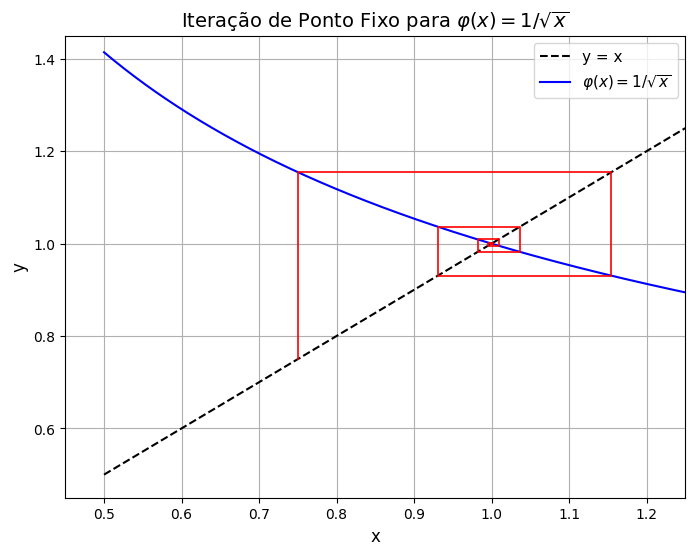

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# quero achar o valor que essa função vai ter quando ela se estabilizar
def funcao_phi(x):
  # a função pedida
  return 1 / np.sqrt(x)

# valor inicial
x0 = 0.75
# quantas vezes repete o processo
n_iter = 20

# criar as listas que definem a trajetoria em vermelho de x e y
# x começa em x0 e y começa em y=x
x_pontos = [x0]
y_pontos = [x0]

x_atual = x0

for i in range(n_iter):
  # usar a função em x0 vai gerar um valor que sera o proximo x usado
  x_prox = funcao_phi(x_atual)

  # o valor encontrado sera o y que coincide com a linha azul
  # (x,y): (x0,x0) --> (x0,f(x0))
  x_pontos.append(x_atual)
  y_pontos.append(x_prox)

  # (x,y): (x0,f(x0)) --> (f(x0),f(x0))
  x_pontos.append(x_prox)
  y_pontos.append(x_prox)

  # substitui o valor usado em x e repete o processo n vezes
  x_atual = x_prox

# criar a imagem
plt.figure(figsize=(8, 6))
# divide o eixo x em 400 partes
x_grid = np.linspace(0.5, 1.25, 400)
# repete pro eixo y
y_grid = x_grid
# valores de y correspondentes aos x do eixo x
y_grid_funcao_phi = funcao_phi(x_grid)

# plota a reta preta tracejada
plt.plot(x_grid, y_grid, 'k--', linewidth=1.5, label='y = x')
# plota a curva azul que eh da nossa função phi
plt.plot(x_grid, y_grid_funcao_phi, 'b-', linewidth=1.5, label=r'$\varphi(x) = 1/\sqrt{x}$')
# plota o caminho em vermelho com as listas criadas
plt.plot(x_pontos, y_pontos, 'r-', linewidth=1.2)

plt.title(r'Iteração de Ponto Fixo para $\varphi(x) = 1/\sqrt{x}$', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.xlim(0.45, 1.25)
plt.ylim(0.45, 1.45)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True)
plt.show()

##Q3 - Iteração de Jacobi I

- Considere um sistema de equações:
<table><tbody><tr><td>
$$
\begin{aligned}
3x - y &= 2 \\
-2x + 4y &= 1
\end{aligned}
$$
</td></tr></tbody></table>

- Parte de uma condição inicial $[x_0, y_0]$ e a partir desta atualiza a cada iteração seguindo a regra:

<table><tbody><tr><td>
$$
\begin{aligned}
x_{k+1} &= \frac{1}{3}(2 + y_k) \\
y_{k+1} &= \frac{1}{4}(1 + 2x_k)
\end{aligned}
$$
</td></tr></tbody></table>

- O processo iterativo deve ser executado até que os valores de $x_k$ e $y_k$ estão suficientemente próximo da solução do sistema, i.e., para $k$ suficientemente grande, se denotarmos por $(\bar{x}, \bar{y})$ a solução do sistema:

<table><tbody><tr><td>
$$
|\bar{x} - x_k| < \varepsilon, \quad |\bar{y} - y_k| < \varepsilon
$$
</td></tr></tbody></table>

- Com $\varepsilon$ pequeno. Em analise numérica pode-se demonstrar que para certos tipos de sistemas, independentemente da condição inicial $x_0, y_0$, esse processo iterativo é convergente.


- Programar o processo iterativo de Jacobi e verificar quantas iterações são necessárias para atingir um erro $\varepsilon = 10^{-2}, 10^{-3}, 10^{-4}, \dots, 10^{-8}$. Graficar o número de iterações como função do erro.

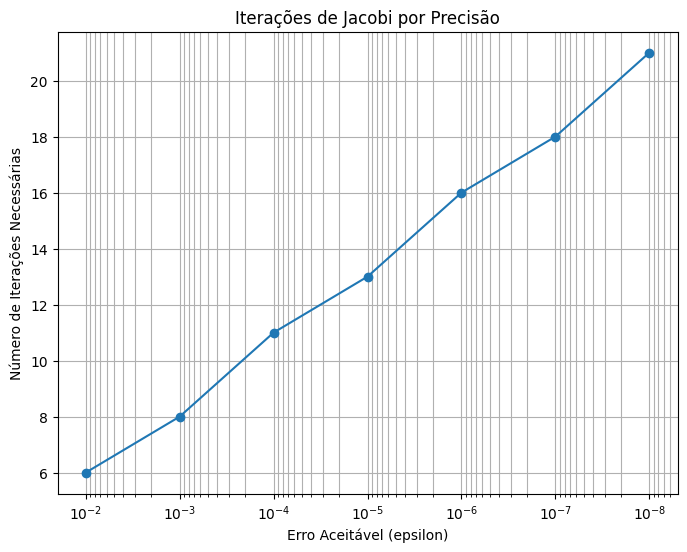

In [ ]:
# pega um sistema de 2 eq, uma com y em função de x e outra com x em função de y
# ele usa um valo x0 para encontrar o y1 e y0 para encontrar o x1
# e entao usa o x1 para encontrar o y2 e y1 para encontrar o x2...
# depois de varias repetiçoes x e y se estabilizam cada um num valor

# o epsilon eh o erro, quando atingir esse valor, significa que ja esta vom o suficiente

import numpy as np
import matplotlib.pyplot as plt

# os valores estaveis que queremos chegar
x_exato = 0.9
y_exato = 0.7

# vai do menos pro mais exigente
lista_erros = [10**(-2), 10**(-3), 10**(-4), 10**(-5), 10**(-6), 10**(-7), 10**(-8)]
# quantas iterações foram necessarias
n_inter = []

for erro_maximo in lista_erros:
  # começa com 0,0
  x_atual = 0
  y_atual = 0
  # quantidade de iterações para esse erro
  contador = 0

  while True:
    # atualizar os valores de x e y
    x_novo = (2 + y_atual) / 3
    y_novo = (1 + 2 * x_atual) / 4
    contador += 1

    # ve a diferença entre o valor encontrado e o esperado
    diferenca_x = abs(x_novo - x_exato)
    diferenca_y = abs(y_novo - y_exato)

    # se a diferença for maior que o erro repete tudo ate se tornar menor
    if diferenca_x < erro_maximo and diferenca_y < erro_maximo:
      break

    # atualizar o valor de x e y
    x_atual = x_novo
    y_atual = y_novo

  # determina o valor de quantos iterações antes do break
  n_inter.append(contador)


plt.figure(figsize=(8, 6))
plt.plot(lista_erros, n_inter, 'o-')
plt.xscale('log')
# inverter a ordem do eixo x do maior pro menor pra seguir a ordem da lista dada
plt.gca().invert_xaxis()
plt.xlabel('Erro Aceitável (epsilon)')
plt.ylabel('Número de Iterações Necessárias')
plt.title('Iterações de Jacobi por Precisão')
plt.grid(True, which="both", ls="-")
plt.show()

##Q4 - Iteração de Jacobi II

- Programar o processo iterativo de Jacobi para o sistema de $3 \times 3$ da sequência:

<table><tbody><tr><td>
$$
\begin{bmatrix}
3 & -1 & -1 \\
-1 & 3 & -1 \\
-1 & -1 & 3
\end{bmatrix}
\begin{bmatrix}
x \\
y \\
z
\end{bmatrix}
=
\begin{bmatrix}
1 \\
2 \\
3
\end{bmatrix}
$$
</td></tr></tbody></table>

In [ ]:
import numpy as np

# o primeiro valor
x = 0
y = 0
z = 0

# usar o erro de 10^-6
erro_max = 10**(-6)
iteracoes = 0

# segue a mesma lógica do exercício anterior mas com 3 variaveis
while True:
  iteracoes += 1

  x_novo = (1 + y + z) / 3
  y_novo = (2 + x + z) / 3
  z_novo = (3 + x + y) / 3

  dif_x = abs(x_novo - x)
  dif_y = abs(y_novo - y)
  dif_z = abs(z_novo - z)

  if dif_x < erro_max and dif_y < erro_max and dif_z < erro_max:
    x, y, z = x_novo, y_novo, z_novo
    break

  x, y, z = x_novo, y_novo, z_novo

print(f"Solução encontrada em {iteracoes} iterações:")
print(f"x = {x}")
print(f"y = {y}")
print(f"z = {z}")

##Q5 - Iteração de Jacobi III

- Programar o método de Jacobi para um sistema geral de equações em que a matriz $A \in \mathbb{R}^{n \times n}$ e o vetor de lado direito $\mathbf{b} \in \mathbb{R}^n$ são dados, i.e.,

<table><tbody><tr><td>
$$
A =
\begin{bmatrix}
a_{11} & a_{12} & \dots & a_{1n} \\
a_{21} & a_{22} & \dots & a_{2n} \\
\cdot & & & \cdot \\
\cdot & & & \cdot \\
a_{n1} & a_{n2} & \dots & a_{nn}
\end{bmatrix},
\quad
b =
\begin{bmatrix}
b_1 \\
b_2 \\
\cdot \\
\cdot \\
b_n
\end{bmatrix}
$$
</td></tr></tbody></table>

- Notar que neste sistema não conhecemos facilmente a solução, justamente, a ideia do método proposto é achar ela, por tanto não podemos avaliar a grandeza $|\bar{x}^i - x_k^i|$, onde o supraíndice refere-se à $i$-éssima incógnita e o subíndice à $k$-éssima iteração. Então, nesse caso como podemos saber em que momento parar o processo iterativo? Pense alguma alternativa.

In [ ]:
'''
COMO FUNCIONA A ITERAÇÃO JACOBI

~ vamos usar de ex um sistema de 3 incognitas e 3 equações ~

queremos encontrar os valores exatos de x, y, z da equação
mas pra encontra x, precisa saber quem e y e z, e y, quem e x e z
caindo num ciclo vicioso, entao esse método chuta um valor qualquer tipo
qual eh x se y,z = 0,0 ? e de y se x,z = 0,0? e z se x,y = 0,0?
dai encontramos um valor para x, para y e para z que sao diferentes de 0,0,0
substituimos esses valores novos no lugar de (0,0,0)
acontece que depois de repetir varias vezes o vetor novo fica cada vez mais pareido com o anterio
isso significa que esses valores realmente solucionam esse sistema
dai a gente acha o valor das incognicas com chute e repetição

--------------------------------------------------
A FÓRMULA GENÉRICA DO JACOBI

    [A00, A01, ..., A0n]      [x0]        [b0]
A = [A10, A11, ..., A1n], x = [x1]  e b = [b1]
            ...              ...         ...
    [An0, An1, ..., Ann]      [xn]        [bn]

primeira linha fica:
A11.x1 + A12.x2 + ... + A1n.xn = b1
   ==> x1 = [b1 - (A12.x2 + ... + A1n.xn)]/ A11

ou seja, podemos escrever de maneira geral:
xi = [b1 - SOMATÓRIA(Aij.xj)]/Aii
                 |
                 |_ todos os valores de j (ate n) menos j=i

--------------------------------------------------------------------------------
ESTRATÉGIA

1. vamos tratar a matriz das incognitas como x = [x0, x1, x2, ...],
   nao da o nome de x, y, z, pois o numero de incognitas nao eh fixo

2. teremos um array sempre novo e velho, se a diferença entre eles for pequena,
   (menor que o erro), eh pq os valores estabilizaram

--------------------------------------------------------------------------------
'''

import numpy as np

# pegar a matriz e o vetor do exemplo anterior
# para testar o codigo, mas sem saber sua dimensao antes

# tranformar os valores da matriz em float para nao arredondar
A = np.array([
    [3, -1, -1],
    [-1, 3, -1],
    [-1, -1, 3]
], dtype=float)

b = np.array([1, 2, 3], dtype=float)

# acha o tamanha da dimensão dessa matriz quadratica, que eh a mesma do vetor
n = len(b)
# zera a matriz das incognitas pra começar (igual aos ex anteriores)
x_velho = np.zeros(n)

# erro máximo desejado
erro_max = 10**(-6)
# colocar um limite pra nao rodar infintamente
inter_max = 100
# iniciar a contagem
iteracoes = 0

while iteracoes < inter_max:
  iteracoes += 1
  x_novo = np.zeros(n)

  # aplicando a formula la de cima
  for i in range(n):
    somatoria = 0
    for j in range(n):
      if j != i:
        somatoria += A[i][j] * x_velho[j]
    x_novo[i] = (b[i] - somatoria) / A[i][i]

  '''
  ex:
      [A00, A01, A02]      [x0]        [b0]
  A = [A10, A11, A12], x = [x1]  e b = [b1]
      [A20, A21, A22]      [x2]        [b2]

  onde A.x = b
  x_velho = [0,0,0] (1° iteraçao apenas)

  x0_novo = [b0 - (A01.x1_velho + A02.x2_velho)]/ A00
  x1_novo = [b1 - (A01.x1_velho + A02.x2_velho)]/ A00
  x2_novo = [b2 - (A01.x1_velho + A02.x2_velho)]/ A00
    ==> x_velho = x_novo

  x_novo = [0,0,0] queremos encontrar os novos valores
  usando os que acabando de achar (velho) dentro da equação
  '''

  # quero saber a maior mudança (de um valor) entre um lista e outra
  distancia = np.max(np.abs(x_novo - x_velho))

  if distancia < erro_max:
    x_velho = x_novo
    break

  # usa o copy para garantir a independencia desse vetor e nao ficar um ligado no outro
  x_velho = x_novo.copy()

print(f"Convergiu em {iteracoes} iterações.")
print(f"Solução aproximada: {x_velho}")

##Q6 - Método de Newton

- Dada uma função $f(x)$ cujos zeros querem ser achados, o processo iterativo:

<table><tbody><tr><td>
$$
x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}
$$
</td></tr></tbody></table>

- Dependendo da função $f$ e do valor inicial $x_0$, o processo iterativo pode convergir a um valor $\bar{x}$ tal que $f(\bar{x}) = 0$ (i.e., uma raiz de $f$). O processo dever ser executado até que o valor de $x_k$ está suficientemente próximo da solução da equação. Em analise numérica, pode-se demonstrar que dependendo da função $f$ e do valor escolhido para $x_0$, esse processo iterativo é convergente.

- Implementar em python o processo iterativo de Newton do exemplo (e), para encontrar as duas raizes no intervalo $[0,2]$ da função:

<table><tbody><tr><td>
$$
f(x) = x \, e^{-x^2} - 0.1
$$
</td></tr></tbody></table>

- Primeiro plotar a função no intervalo $[-1,2]$. Baseado no gráfico da função escolher pontos iniciais $x_0$ que estejam próximos das raizes procuradas. Escolher um erro $\varepsilon$ pequeno e determinar quantas iterações são necessárias para a convergência do método.


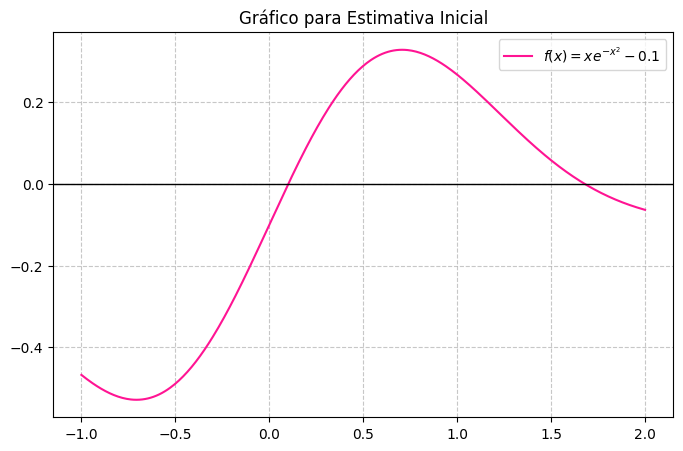

Chutando x = 0.5 encontramos a raíz x = 0.101026, com 5 iterações.
Chutando x = 1.5 encontramos a raíz x = 1.679631, com 4 iterações.


In [ ]:
'''
o objetivo eh encontrar x0 (raíz) para y = 0
temos uma função f(x)
começa chutanto um valor x = xa
encontra a reta tangente ao ponto (xa, f(xa))
pega onde essa reta cruza o eixo x (y=0)
esse ponto sera (xn, 0)
como a reta tangente segue a direção da curva, geralmente xn ta mais perto de x0 do que xa
dai repete varias vezes

~ para achar esse novo valor de x usamos a linearização:
y - y0 = m(x - x0)

estamos parados em (xa, f(xa)) e sabemos e a derivada nesse ponto vale f'(xa)
queremos a intersecao dessa reta tangente (m=f'(xa)) com o eixo x (y=0)
chegando no pont (xn, 0)

0 - f(xa) = f'(xa)(xn - xa) ==> xn = xa - f(xa)/f'(xa)

dai calculamos a distancia entre xn e xa, quando essa distancia for muito pequeneninha
significa que xn = xa, ou seja f(xa) = 0, se f(xa) = 0 entao xa é a raiz da funcao (y=0)

OBS: o metodo so enxerga o grafico perto do chute inicial, entao pode ser ter tenha mais de uma raiz
'''
import numpy as np
import matplotlib.pyplot as plt

# função dada
def f(x):
  return x * np.exp(-x**2) - 0.1

# derivada da função dada
def df(x):
  return np.exp(-x**2) * (1 - 2*x**2)

def metodo_newton(x0):

    erro_max = 10**(-6) # diferença maxima entre xa e xn
    max_iter = 100 # limite de iterações

    xa = x0
    iteracoes = 0

    for i in range(max_iter):
        iteracoes += 1
        fxa = f(xa)
        dfxa = df(xa)

        if dfxa == 0: # verificar se a derivada nao eh zero pq nao da pra dividir
            print("Derivada zero")
            return None

        # aplicando a formula la de cima
        xn = xa - (fxa / dfxa)

        erro = abs(xn - xa)

        if erro < erro_max:
            print(f"Chutando x = {x0} encontramos a raíz x = {xn:.6f}, com {iteracoes} iterações.")
            return xn, iteracoes # retorna dois valores

        xa = xn

    print("Número máximo de iterações atingido sem convergência.")
    return None

#--------------------------------------------------------------------------------#
x_plot = np.linspace(-1, 2, 400)
y_plot = f(x_plot)
plt.figure(figsize=(8, 5))
plt.plot(x_plot, y_plot, label=r'$f(x) = x e^{-x^2} - 0.1$', color='deeppink')
plt.axhline(0, color='black', linewidth=1) # Linha do eixo zero
plt.grid(True, linestyle='--', alpha=0.7)
plt.title('Gráfico para Estimativa Inicial')
plt.legend()
plt.show()
#--------------------------------------------------------------------------------#

# Usando dois valores diferentes de x0 no intervalo [0,2] pra testar
raiz1, iter1 = metodo_newton(x0=0.5)
raiz2, iter2 = metodo_newton(x0=1.5)



##Q7 - Método das potencias
- Dada uma matriz $A \in \mathbb{R}^{n \times n}$ e um vetor $\mathbf{x}_0 \in \mathbb{R}^n$ de norma unitaria, no método das potencias calcula-se um novo vetor $\mathbf{x}_{k+1}$ e um escalar $\lambda_{k+1}$ a partir do vetor anterior seguindo a regra

<table><tbody><tr><td>
$$
\mathbf{y}_{k+1} = A \mathbf{x}_k, \quad \mathbf{x}_{k+1} = \frac{\mathbf{y}_{k+1}}{\|\mathbf{y}_{k+1}\|}, \quad \lambda_{k+1} = \mathbf{x}_{k+1}^T A \mathbf{x}_{k+1}
$$
</td></tr></tbody></table>

- Notar que $\mathbf{y}_{k+1} = A \mathbf{x}_k = A^2 \mathbf{x}_{k-1} = \dots = A^{k+1} \mathbf{x}_0$. Dependendo da matriz $A$, o método converge ao autovetor $\bar{\mathbf{x}}$ correspondente ao autovalor dominante $\bar{\lambda}$ da matriz (i.e., o autovalor de maior módulo).

- Implementar o método das potencias do exemplo (f) nas matrizes

<table><tbody><tr><td>
$$
A =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 2 & 0 \\
0 & 0 & 3
\end{bmatrix}
$$
</td></tr></tbody></table>

<table><tbody><tr><td>
$$
A = \text{diag}(a_1, a_2, \dots, a_n)
$$
</td></tr></tbody></table>

- sendo $a_i$s números randômicos uniformemente distribuídos entre 0 e 1.




In [ ]:
# o metodo rotaciona e normaliza um vetor varias vezes ate ele convergir numa direção
# essa direção eh o autovetor e seu lambda eh o autovalor

import numpy as np

def metodo_das_potencias(A):
  max_iter = 100
  tolerancia = 10**(-6)

  # achar a dimensão n da matriz para gerar um vetor de mesma dimensao
  n = A.shape[0]
  # gerar o vetor aleatorio x0
  x = np.random.rand(n)
  # normalizando esse vetor x0 como pedido
  x = x / np.linalg.norm(x)
  # como lambda vai convergir, vamo chutar um valor aleatorio para começar
  lambda_velho = 0

  for k in range(max_iter):
    # usando a formula --> y = A.v
    y = np.dot(A, x)
    norma = np.linalg.norm(y)
    # achando o vetor y normalizado (x) --> x = y/||y||
    if norma == 0:
      break
    x_novo = y / norma
    # usando a formula --> lambda = x(T).A.x
    lambda_novo = np.dot(x_novo.T, np.dot(A, x_novo))

    # como o metodo diz que lambda vai convergir
    # isso significa que seu valor varia menos que o erro definido
    # ou seja, quase nao varia, quanto menor o erro maior a precisao
    erro = np.abs(lambda_novo - lambda_velho)
    if erro < tolerancia:
      return lambda_novo, x_novo
    # caso contrario, continua com o novo x
    x = x_novo
    lambda_velho = lambda_novo
  # ele retorna o lambda e aquele x normalizado
  return lambda_novo, x_novo

#_____________________________________________________________________________#

# EX1: usando a matriz dada
A1 = np.array([
    [1, 0, 0],
    [0, 2, 0],
    [0, 0, 3]
], dtype=float) # transformar a matriz em float para nao arredondar

lambda_calc, v_calc = metodo_das_potencias(A1)

print(f"Autovalor dominante: {lambda_calc:.2f}")
print(f"Autovetor dominante: {np.round(v_calc, 3)}")


# EX2: criando uma matriz diagonal aleatoria de dimensao n
n = 5
# achando os valores da diagona entre 0 e 1
elementos_diag = np.random.uniform(0, 1, n)
# criando uma matriz diagonal com os valores acima
A2 = np.diag(elementos_diag)

lambda_calc_2, v_calc_2 = metodo_das_potencias(A2)

print(f"Elementos da diagonal: {np.round(elementos_diag, 3)}")
print(f"Autovalor dominante: {lambda_calc_2:.3f}")
print(f"Autovetor dominante: {np.round(v_calc_2, 3)}")


### MINI PROJETO

Considere que corda de comprimento L foi particionada em $N$ intervalos. E considere dois casos de densidade dessa corda (constante e variavel):

* Comprimento da corda: $L = 1 \, \text{m}$
* Tensão na corda: $\sigma = 2 \, \text{N}$
* Aceleração da gravidade: $g = 9.8 \, \text{m/s}^2$
* N_valores = [10, 20, 40, 80]
* $\rho_c(x) = 1 \, \text{kg/m}$
* $\rho_v(x) = \frac{1}{2}\left(1 + e^{-100(x-\frac{1}{2})^2}\right) \, \text{kg/m}$





PARTE 1

1. Desenvolva uma função em Python para calcular a massa das partículas para os valores de N nos dois casos de densidades. Depois plote num gráfico 1.1 os resultados das massas para a densidade constante para cada um dos valores de N, e no grafico os valores para densidade variavel.

2. Depois implemente um método iterativo utilizando as Iterações de Jacobi para encontrar a posição de equilíbrio das massas: a posição da $i$-ésima massa é determinada a partir das posições das massas vizinhas calculadas na iteração anterior. Depois plote num gráfico 2.1 a forma de equilíbrio da corda para a densidade constante para cada um dos valores de N, e no grafico 2.2 os valores para densidade variavel.

3. Depois implemente o método iterativo conhecido como Esquema de Gauss-Seidel para encontrar a posição de equilíbrio: para encontrar a posição da massa i, utiliza-se a posição da massa i+1 e da i-1. Depois plote num gráfico 3.1 a forma de equilíbrio da corda para a densidade constante para cada um dos valores de N, e no grafico 3.2 os valores para densidade variavel.

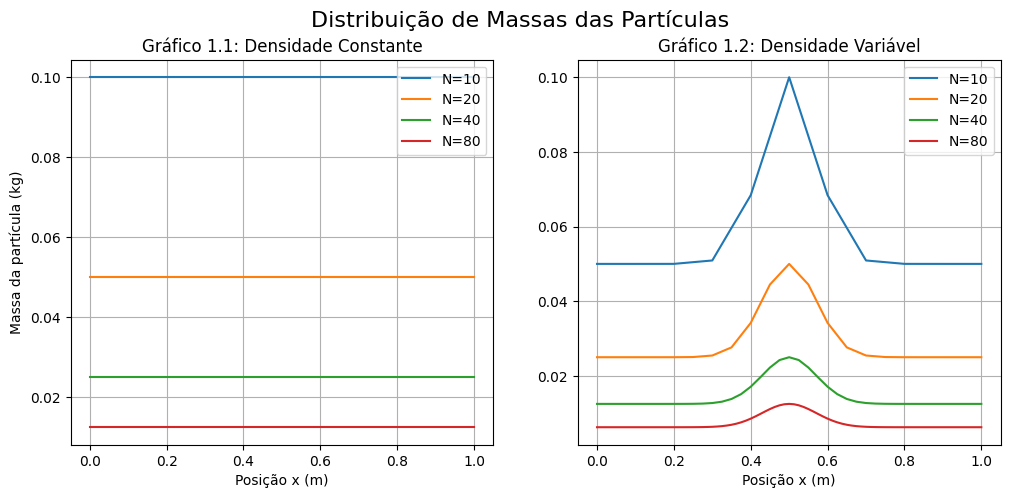

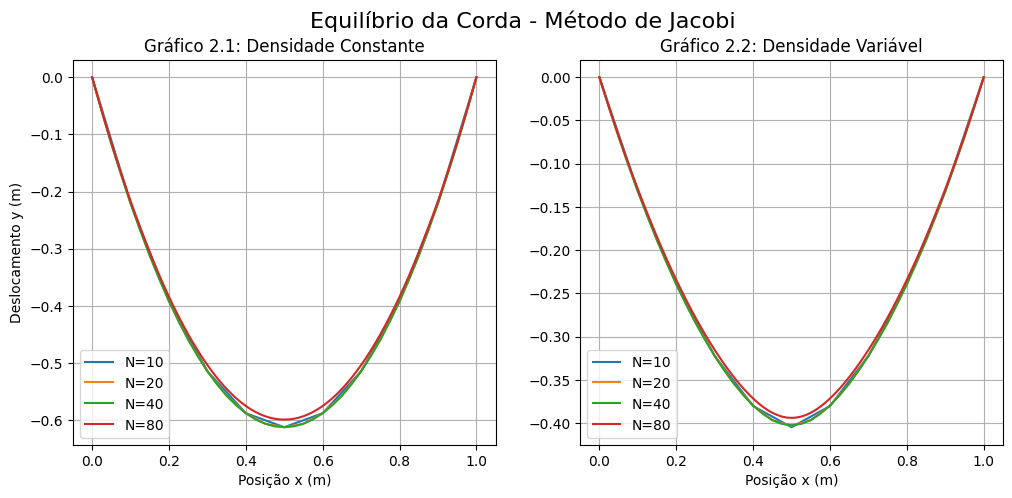

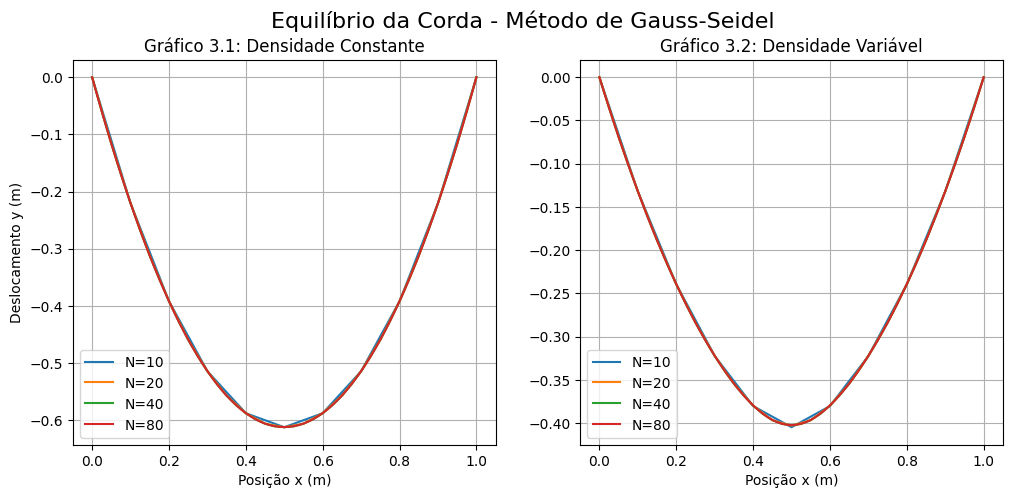

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

L = 1.0
tensao = 2.0
g = 9.8
N_valores = [10, 20, 40, 80]

def rho_constante(x):
    # cria um array so de 1.0 do mesmo tamanho que o vetor x
    return np.ones(len(x))

def rho_variavel(x):
    return 0.5 * (1 + np.exp(-100 * (x - 0.5)**2))


# 1. CALCULANDO AS MASSAS

'''
dividindo a corda L em N partes, cada parte tem tamanho dx
calculamos a massa de cada pedaçinho a partir da densidade de seus centros de massa
mi = p(x).dx
'''

def calcular_massas(N, funcao):
    dx = L / N
    # cria um vetor x com as posições do centro de cada parte de N
    x = np.linspace(0, L, N+1)
    m = funcao(x) * dx
    # retorna o dx para usar nas outras funções abaixo
    return x, m, dx


# 2. CALCULANDO EQUILIBRIO PELO MÉTODO JACOBI

'''
queremos encontrar o equilibro y(x) de um corda de tensão T, sujeita a gravidade
para pequenos angulos temos que uma relação com a segunda derivada

T.y(x)" = p(x).g

quando dividimos a corda em N pedacinhos de dx

y(x)" = [y(i+1) - 2yi + y(i-1)]/(dx)^2

chegando a equação de recorrencia

yi = [y(i+1) + y(i-1) - mi.g.dx/T]/2

fator_força = mi.g.dx/T, eh uma lista que depende da massa e
sera constante para todas as iterações

1° iteração:

         0 1 2 3 4
    y = [0 0 0 0 0]

                y0 y2
    y1 = 0,5 x (0 + 0 - 2) = -1
                y1 y3
    y2 = 0,5 x (0 + 0 - 2) = -1
                y2 y4
    y3 = 0,5 x (0 + 0 - 2) = -1

   2° iteração:

          0  1  2  3 4
    yn = [0 -1 -1 -1 0]

                yn0 yn2
    yn1 = 0,5 x (0 -1 - 2) = -1.5
                yn1 yn3
    yn2 = 0,5 x (-1 -1 - 2) = -2.0
                yn2 yn4
    yn3 = 0,5 x (-1 + 0 - 2) = -1.5


    vai chegar num pontos de essas listas vai ficar muito parecidas
    elas variam menos que o erro tolerado, levando a crer que eh os valores estabilizaram

'''

def jacobi(N, funcao):
  erro = 10**(-6)
  max_iter = 5000
  x, m, dx = calcular_massas(N, funcao)

  # nesse metodo usamos duas listas
  y = np.zeros(len(x))
  y_novo = np.zeros(len(x))

  # usando a lista m calculando pela função anterior
  fator_forca = (m * g * dx) / tensao

  for k in range(max_iter):
    # aplicando a formula acima
    # [1:-1] nao pega o primeiro nem o ultimo pois sao valores de contorno y = 0
    #    yi                y(i-1)  y(i+1)
    y_novo[1:-1] = 0.5 * (y[0:-2] + y[2:] - fator_forca[1:-1])
    #        ignorar os 2 ultimos | ignora os dois primeiros
    # isso para que todos tenham o mesmo tamanho

    # calcula o modulo do vetor
    if np.linalg.norm(y_novo - y) < erro:
      y = np.copy(y_novo)
      break
    y = np.copy(y_novo)

  # retorna os eixos do gráfico
  return x, y

# 3. CALCULANDO EQUILIBRIO PELO MÉTODO GAUSS
'''
nesse metodo usamos a informação mais recente

iteração 1:
            y0    y2
y1 = 0.5 x (0.0 + 0.0 - 2.0) = -1.0

iteração 2: JA ATUALIZA Y1!!
            y1    y3
y2 = 0.5 x (-1 + 0.0 - 2.0) = -1.0

'''
def gauss(N, funcao):
  erro = 10**(-6)
  max_iter = 5000
  x, m, dx = calcular_massas(N, funcao)
  y = np.zeros(len(x))

  fator_forca = (m * g * dx) / tensao
  num_pontos = len(y)

  for k in range(max_iter):
    y_velho = np.copy(y)

    for i in range(1, num_pontos - 1):
      y[i] = 0.5 * (y[i-1] + y[i+1] - fator_forca[i])

    if np.linalg.norm(y - y_velho) < erro:
      break

  # retorna os eixos do gráfico
  return x, y


# PLOTANDO TODOS OS GRÁFICOS

# GRÁFICO 1:
fig1, (ax1_1, ax1_2) = plt.subplots(1, 2, figsize=(12, 5))
fig1.suptitle('Distribuição de Massas das Partículas', fontsize=16)

for N in N_valores:
    x, m, _ = calcular_massas(N, rho_constante)
    ax1_1.plot(x, m, label=f'N={N}')

    x_v, m_v, _ = calcular_massas(N, rho_variavel)
    ax1_2.plot(x_v, m_v, label=f'N={N}')

ax1_1.set_title('Gráfico 1.1: Densidade Constante')
ax1_1.set_xlabel('Posição x (m)')
ax1_1.set_ylabel('Massa da partícula (kg)')
ax1_1.legend()
ax1_1.grid(True)

ax1_2.set_title('Gráfico 1.2: Densidade Variável')
ax1_2.set_xlabel('Posição x (m)')
ax1_2.legend()
ax1_2.grid(True)
plt.show()

# GRÁFICO 2:
fig2, (ax2_1, ax2_2) = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle('Equilíbrio da Corda - Método de Jacobi', fontsize=16)

for N in N_valores:
    x, y = jacobi(N, rho_constante)
    ax2_1.plot(x, y, label=f'N={N}')
    x_v, y_v = jacobi(N, rho_variavel)
    ax2_2.plot(x_v, y_v, label=f'N={N}')

ax2_1.set_title('Gráfico 2.1: Densidade Constante')
ax2_1.set_xlabel('Posição x (m)')
ax2_1.set_ylabel('Deslocamento y (m)')
ax2_1.legend()
ax2_1.grid(True)

ax2_2.set_title('Gráfico 2.2: Densidade Variável')
ax2_2.set_xlabel('Posição x (m)')
ax2_2.legend()
ax2_2.grid(True)
plt.show()

# GRÁFICO 3:
fig3, (ax3_1, ax3_2) = plt.subplots(1, 2, figsize=(12, 5))
fig3.suptitle('Equilíbrio da Corda - Método de Gauss-Seidel', fontsize=16)

for N in N_valores:
    x, y = gauss(N, rho_constante)
    ax3_1.plot(x, y, label=f'N={N}')
    x_v, y_v = gauss(N, rho_variavel)
    ax3_2.plot(x_v, y_v, label=f'N={N}')

ax3_1.set_title('Gráfico 3.1: Densidade Constante')
ax3_1.set_xlabel('Posição x (m)')
ax3_1.set_ylabel('Deslocamento y (m)')
ax3_1.legend()
ax3_1.grid(True)

ax3_2.set_title('Gráfico 3.2: Densidade Variável')
ax3_2.set_xlabel('Posição x (m)')
ax3_2.legend()
ax3_2.grid(True)
plt.show()

PARTE 2

4. Considere rho = 1 e N = 80. Aplique uma força vertical para baixo, denotada por $f_{39}$, atuando exclusivamente na massa $i = 39$. Varie o valor dessa força $f_{39}$ e plote o deslocamento sofrido por esse ponto em função da força aplicada no grafico 1.

5. Agora aplique uma força vertical para cima na massa $i = 17$ e aplique simultaneamente uma força vertical para baixo na massa $i = 30$. Calcule e plote a forma de equilíbrio resultante da corda, no grafico 2.

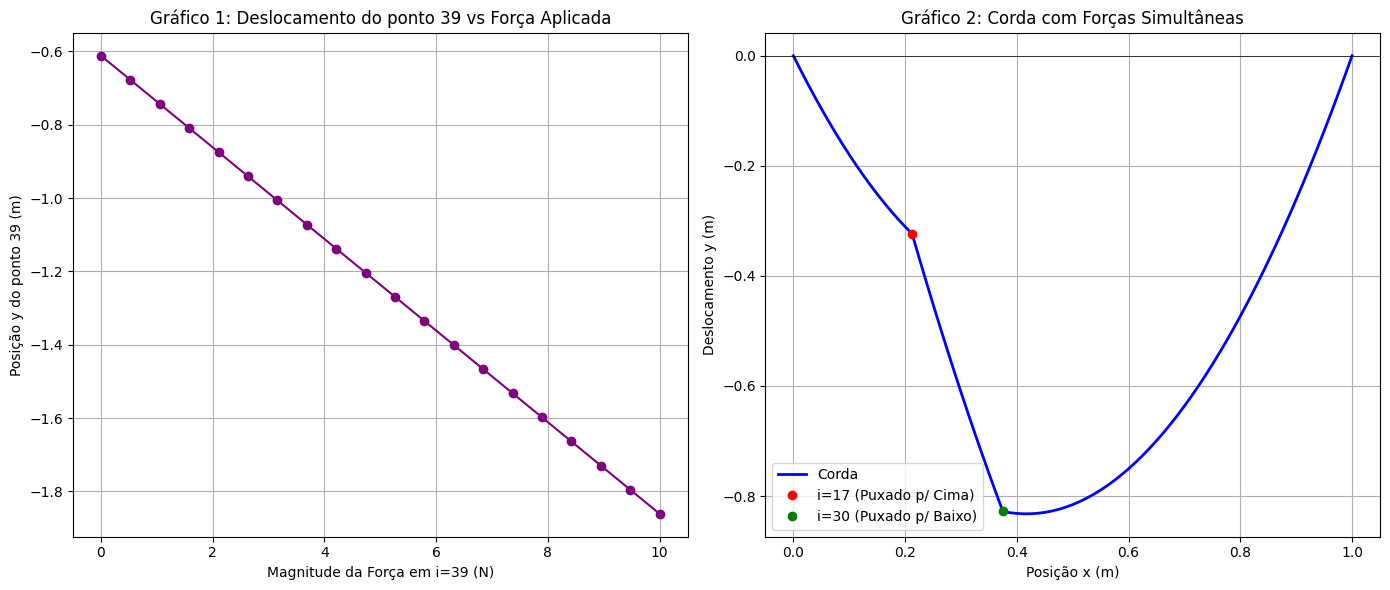

In [ ]:
'''
F(x) = T.y(x)"

discretizando temos uma aproximação:

y(x)" = [y(i+1) - 2yi + y(i-1)]/(dx)^2

yi = [y(i+1) + y(i-1) - Fi.dx/T]/2
vamo fazer essa iteração usando gauss

'''

import numpy as np
import matplotlib.pyplot as plt

L = 1.0
tensao = 2.0
g = 9.8
N = 80
rho = 1.0

# recebe um dicionario que diz em qual parte tem uma força extra
def gauss(N, forcas_extras):
  erro = 10**(-6)
  max_iter = 10000
  dx = L / N
  x = np.linspace(0, L, N+1)
  # lista das massas de cada dx que eh a mesma
  m = np.ones(len(x)) * dx * rho
  # força da gravidade
  F_total = m * g

  # adiciona no dicionario a força extra f que for dada naquela chave especifica
  for i, f in forcas_extras.items():
    F_total[i] += f

  # aplicando a formula la de cima
  fator_forca = (F_total * dx) / tensao
  y = np.zeros(len(x))

  for k in range(max_iter):
    y_velho = np.copy(y)
    for i in range(1, len(y) - 1):
      y[i] = 0.5 * (y[i-1] + y[i+1] - fator_forca[i])

    if np.linalg.norm(y - y_velho) < erro:
      break

  # retorna o eixo x dos valores de x, e o eixo y com o deslocamento horizontal
  return x, y

# GRÁFICO 1: DESLOCAMENTO Y VS FORÇA

# fazer 20 espaços entre 0 e 10 Newtons que sera nosso eixo x
forcas_teste = np.linspace(0, 10, 20)
# sera nosso eixo y
deslocamentos_39 = []

# ele vai testar todos os valores de força teste
for f in forcas_teste:
  # cria um dicionario para usar a função gauss
  dic_forca = {39: f}
  # vai nos da os deslocamento em x que vou ignorar
  # e os valores do deslocamento em y para cada força
  i, y_res = gauss(N, dic_forca)
  # adiciona na lista que criamos
  deslocamentos_39.append(y_res[39])

# GRAFICO 2

# adiciona so nesses dois itens
f_cima = -5.0
f_baixo = 5.0
dic_cenario_2 = {17: f_cima, 30: f_baixo}
x_final, y_final = gauss(N, dic_cenario_2)


# PLOTANDO OS GRAFICOS

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(forcas_teste, deslocamentos_39, '-o', color='purple')
plt.title('Gráfico 1: Deslocamento do ponto 39 vs Força Aplicada')
plt.xlabel('Magnitude da Força em i=39 (N)')
plt.ylabel('Posição y do ponto 39 (m)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x_final, y_final, 'b-', linewidth=2, label='Corda')
plt.plot(x_final[17], y_final[17], 'ro', label='i=17 (Puxado p/ Cima)')
plt.plot(x_final[30], y_final[30], 'go', label='i=30 (Puxado p/ Baixo)')

plt.title('Gráfico 2: Corda com Forças Simultâneas')
plt.xlabel('Posição x (m)')
plt.ylabel('Deslocamento y (m)')
plt.axhline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

PARTE 3

6. Considere que a corda está imersa em um fluido de densidade rho_f = 1000, que a densidade volumétrica do material da corda é bar = 900, e que a forças externas (exceto peso e empuxo) são nulas. O diâmetro da corda varia com a posição $x$, dado pela função:
$$\phi(x) = 2\left(1 + e^{-200(x-\frac{1}{2})^2}\right)$$

- O volume da corda deve ser calculado e distribuído sobre as partículas para determinar a força $f_i^b$, onde $v_i$ é o volume associado à partícula $i$.
$$f_i^b = \rho_f v_i g$$

- Calcule a nova forma de equilíbrio da corda sob estas condições e plote o resultado.

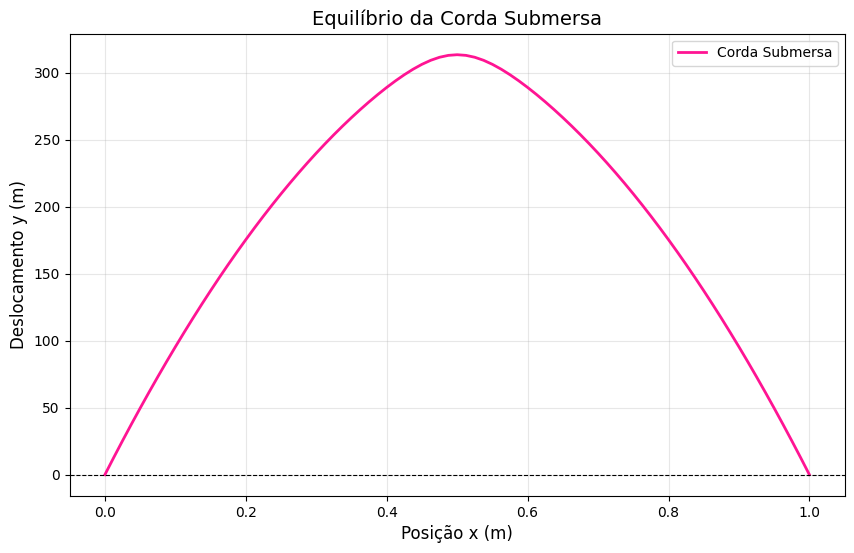

In [ ]:
'''
calculo do volume de cada pedaço da corda:
Ai​=π(2ϕ(xi​)​)2
vi​=Ai​⋅Δx

força resultante
F_{resultante, i} = P_i - E_i = (p(corda) - p(fluido)) v_i g

Como a densidade da corda é menor que a do fluido,
a força resultante sera para cima
'''

import numpy as np
import matplotlib.pyplot as plt

L = 1.0
tensao = 2.0
g = 9.8
N = 80
rho_f = 1000.0
rho_bar = 900.0


def phi(x):
  return 2 * (1 + np.exp(-200 * (x - 0.5)**2))

def resolver_corda_submersa(N):
  erro = 10**(-6)
  max_iter = 10000
  dx = L / N
  x = np.linspace(0, L, N+1)

  diametro = phi(x)
  raio = diametro / 2.0
  area_secao = np.pi * (raio**2)
  volume = area_secao * dx
  peso = (rho_bar * volume) * g
  empuxo = (rho_f * volume) * g
  f_liquida = peso - empuxo
  fator_forca = (f_liquida * dx) / tensao

  y = np.zeros(len(x))

  for k in range(max_iter):
    y_velho = np.copy(y)

    for i in range(1, len(x) - 1):
      y[i] = 0.5 * (y[i-1] + y[i+1] - fator_forca[i])

    if np.linalg.norm(y - y_velho) < erro:
      break

  return x, y

# GRÁFICO
x, y = resolver_corda_submersa(N)
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Corda Submersa', color='deeppink', linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Equilíbrio da Corda Submersa', fontsize=14)
plt.xlabel('Posição x (m)', fontsize=12)
plt.ylabel('Deslocamento y (m)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()